In [2]:
%reload_ext autoreload
%autoreload 2

import os
import sys
import pickle
from tqdm import tqdm

import numpy as np
np.float = np.float64

from mpmath import mp

import healpy as hp
import jax.numpy as jnp

sys.path.append("/n/home07/yitians/fermi/NPTFit/NPTFit")
sys.path.append("/n/home07/yitians/fermi/NPTFit")
from NPTFit import npll

sys.path.append("../nptfit")
from nptfit_func import *

sys.path.append("..")
from utils import create_mask as cm
from models.templates import NFWTemplate, LorimerDiskTemplate
from models.psf import KingPSF
from utils.utils import find_max_point

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file('../notebooks/matplotlibrc')

In [3]:
fct_max = 1000

def log_factorial(m):
    return np.sum(np.log(np.arange(1., m + 1., dtype=np.float128)))

log_factorial_ary = np.vectorize(log_factorial)(np.arange(fct_max))

In [7]:
def incgamma_up_fct_ary(m_max, z, a):
    """ Upper incomplete gamma function / m!

    Calculation performed using gamma function recursion relation.

    Returns:
        float64 numpy array of Gamma(z+m,a)/m! for m in [0,m_max]

    """

    igf_list = np.zeros(m_max + 1, dtype=np.float128)
    igf_list[0] = np.float128(mp.gammainc(z, a))

    # i_array[m] = m+1
    i_array = np.arange(1., m_max + 1., dtype=np.float128)
    
    for i in np.arange(1,m_max+1):
        igf_list[i] = ((i_array[i-1] - 1. + z)*igf_list[i-1]/i 
                      + np.exp((i_array[i-1] - 1. + z)*np.log(a) - a 
                      - log_factorial_ary[i]))

    return np.asarray(igf_list,dtype=np.float64)

def incgamma_lo_fct_ary(m_max, z, a):
    """ Lower incomplete gamma function / m!

    Calculation performed using gamma function recursion relation.
    Starts at m_max and moves backwards for greater precision.

    Returns:
        float64 numpy array of Gamma(z+m,0,a)/m! for m in [0,m_max]

    """

    igf_list = np.zeros(m_max + 1,dtype=np.float128)
    igf_list[m_max] = np.float128(mp.gammainc(z + m_max, 0, a) / mp.factorial(m_max))
    # NB: use mp.factorial, since np.math.factorial overflows for m ~ 170

    # i_array[m] = m_max-m
    i_array = np.arange(m_max, 0, -1, dtype=np.float128)
    
    for i in np.arange(m_max, 0, -1):
        igf_list[i-1] = ((igf_list[i] 
                        + np.exp((i_array[-i] - 1. + np.float128(z))
                        *np.log(np.float128(a)) - np.float128(a) 
                        - log_factorial_ary[i]))*i_array[-i]
                        /(i_array[-i] - 1. + np.float128(z)))

    return np.asarray(igf_list,dtype=np.float64)

def gamma_ary(m_max, z):
    """Gamma(z+m)/m! for m in [0,m_max]"""

    gamma_s = np.vectorize(mp.gamma)(z + np.arange(1+m_max))
    m_fac_s = np.exp(log_factorial_ary[:1+m_max])
    return np.asarray(gamma_s/m_fac_s, dtype=np.float64)

In [35]:
%timeit incgamma_lo_fct_ary(100, 0.5, 0.4)

620 µs ± 998 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [34]:
%timeit gamma_ary(100, 0.5)

1.59 ms ± 9.48 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [43]:
# strategy 2: C5 C6
def return_xs(theta, npt_compressed, data):

    a_ps, n1, n2, n3, sb1, sb2 = theta
    k_max = int(np.max(data) + 1)
    npix_roi = len(npt_compressed)

    x_m_ary = np.zeros((npix_roi, k_max + 1))
    x_m_sum = np.zeros(npix_roi)

    x_m_raw =    incgamma_up_fct_ary(k_max, 1.-n1, sb1)
    x_m_raw +=   incgamma_up_fct_ary(k_max, 1.-n2, sb2) * sb1**(n2-n1)
    x_m_raw += - incgamma_up_fct_ary(k_max, 1.-n2, sb1) * sb1**(n2-n1)
    x_m_raw +=             gamma_ary(k_max, 1.-n3) * sb1**(n2-n1) * sb2**(n3-n2)
    x_m_raw += - incgamma_up_fct_ary(k_max, 1.-n3, sb2) * sb1**(n2-n1) * sb2**(n3-n2)

    x_m_sum_raw =  1 / (n1-1)
    x_m_sum_raw += 1 / (1-n2) * (1 - (sb2/sb1)**(1-n2))
    x_m_sum_raw += 1 / (1-n3) * (sb2/sb1)**(1-n2)

    x_m_ary = a_ps * np.outer(npt_compressed, x_m_raw) * sb1**n1 # (C5) of 1612.03173
    x_m_sum = a_ps * npt_compressed * x_m_sum_raw * sb1 - x_m_ary[p, 0] # (C6) of 1612.03173

    return x_m_ary, x_m_sum

In [ ]:
# strategy 1: use delta f
def return_xs_2break(theta, npt_compressed, data):

    a_ps, n1, n2, n3, sb1, sb2 = theta

    k_max = int(np.max(data) + 1)
    npix_roi = len(npt_compressed)

    x_m_ary = np.zeros((npix_roi, k_max+1))
    x_m_sum = np.zeros(npix_roi)

    g0_ary_f = np.zeros(k_max + 1)
    g1_ary_f = np.zeros(k_max + 1)
    g2_ary_f = np.zeros(k_max + 1)

    f2, df_rho_div_f2 = 0., 0.
    pref0_x_m_ary, pref1_x_m_ary, pref2_x_m_ary = 0., 0., 0.
    first0_x_m_sum_ary, first1_x_m_sum_ary, first2_x_m_sum_ary = 0., 0., 0.
    second0_x_m_sum_ary, second1_x_m_sum_ary, second2_x_m_sum_ary = 0., 0., 0.
    x_m_sum_f, x_m_ary_f = 0., 0.

    f_index, p, k = 0, 0, 0

    first0_x_m_sum_ary = 1/(1-n1)
    first1_x_m_sum_ary = 1/(1-n2)
    first2_x_m_sum_ary = 1/(1-n3)

    second0_x_m_sum_ary = -1.0
    second1_x_m_sum_ary = (1 - pow(sb2/sb1, 1-n2))
    second2_x_m_sum_ary = pow(sb2/sb1, 1-n2)

    for f_index in range(len(f_ary)):
        f2 = float(f_ary[f_index])
        df_rho_div_f2 = df_rho_div_f_ary[f_index]
        
        g0_ary_f = igf.incgamma_up_fct_ary(k_max, 1. - n1, sb1 * f2)
        g1_ary_f = igf.incgamma_up_fct_ary(k_max, 1. - n2, sb2 * f2) \
                   - igf.incgamma_up_fct_ary(k_max, 1. - n2, sb1 * f2)
        g2_ary_f = igf.incgamma_lo_fct_ary(k_max, 1. - n3, sb2 * f2)

        pref0_x_m_ary = pow(sb1 * f2, n1)
        pref1_x_m_ary = pref0_x_m_ary * pow(sb1 * f2, n2 - n1)
        pref2_x_m_ary = pref1_x_m_ary * pow(sb2 * f2, n3 - n2)

        for p in range(npix_roi):
            x_m_sum_f = a_ps * (sb1 * f2) * (first0_x_m_sum_ary*second0_x_m_sum_ary
                        + first1_x_m_sum_ary*second1_x_m_sum_ary
                        + first2_x_m_sum_ary*second2_x_m_sum_ary) \
                        * npt_compressed[p]
            x_m_sum[p] += df_rho_div_f2 * x_m_sum_f

            for k in range(data[p]+1):
                x_m_ary_f = a_ps * (pref0_x_m_ary * g0_ary_f[k] + pref1_x_m_ary
                            * g1_ary_f[k] + pref2_x_m_ary * g2_ary_f[k]) \
                            * npt_compressed[p]
                x_m_ary[p,k] += df_rho_div_f2 * x_m_ary_f

    x_m_sum = np.asarray(x_m_sum) - np.asarray(x_m_ary)[:,0] 

    return np.asarray(x_m_ary), np.asarray(x_m_sum)

In [40]:
DTYPE = np.float64

def log_like(pt_sum_compressed, theta, npt_compressed, data):

    k_max = np.max(data) + 1
    npixROI = len(pt_sum_compressed)
    x_m_ary = np.zeros((npixROI, k_max + 1), dtype=DTYPE)
    x_m_sum = np.zeros(npixROI, dtype=DTYPE)

    i = 0
    x_m_ary_out = np.zeros((npixROI, k_max + 1), dtype=DTYPE)
    x_m_sum_out = np.zeros(npixROI, dtype=DTYPE)

    for i in range(len(theta)):
        x_m_ary_out, x_m_sum_out = return_xs(np.array(theta[i]), npt_compressed[i], data)
        x_m_ary += np.asarray(x_m_ary_out)
        x_m_sum += np.asarray(x_m_sum_out)

    return log_like_internal(pt_sum_compressed, data, x_m_ary, x_m_sum, k_max, npixROI)

def log_like_internal(pt_sum_compressed, data, x_m_ary, x_m_sum, k_max, npixROI):

    pk = np.zeros((k_max+1), dtype=DTYPE)

    # Loop over pixels
    ll = 0.
    for p in range(npixROI):
        # Define p_0 (pk[0]) and p_1 (pk[1])
        # Then the remaining p_k are determined recursively up to the value of 
        # k = data in that pixel
        f0_ary = -(pt_sum_compressed[p] + x_m_sum[p])
        f1_ary = (pt_sum_compressed[p] + x_m_ary[p,1])
        pk[0] = np.exp(f0_ary)
        pk[1] = pk[0] * f1_ary

        for k in range(2, data[p]+1):
            pk[k] = 0.
            for n in range(0, k-1):
                pk[k] += (k-n)/float(k)*x_m_ary[p,k-n]*pk[n]
            pk[k] += f1_ary*pk[k-1]/float(k)

        # Need prob > 0 to define a LL
        # If a very bad fit can get prob = 0, if so then penalise to avoid this region
        if pk[data[p]] > 0:
            ll += np.log(pk[data[p]])
        else:
            ll += -10.1**10.

    return ll

## 1 pixel

In [27]:
pt_sum_compressed = np.array([0.])
npt_compressed = np.array([[1.]])
data_s = [
    np.array([3], dtype=np.int64),
    np.array([7], dtype=np.int64),
    np.array([12], dtype=np.int64),
]

Sps_arr = np.linspace(0.1, 15, 100)

ll_ss = []
for data in data_s:
    ll_s = []
    for Sps in Sps_arr:
        s0 = 5
        a = Sps / s0
        theta = [[a, s0]]
        ll = log_like(pt_sum_compressed, theta, npt_compressed, data)
        ll_s.append(ll)
    ll_ss.append(ll_s)

In [ ]:
plt.plot(Sps_arr, ll_ss[0], label='data = 3')
plt.plot(Sps_arr, ll_ss[1], label='data = 7')
plt.plot(Sps_arr, ll_ss[2], label='data = 12')
plt.axvline(3, color='k', ls='--')
plt.axvline(7, color='k', ls='--')
plt.axvline(12, color='k', ls='--')
plt.legend()

## N pixels

In [10]:
# multiple templates
n_pix = 100
vd_base = dict(
    Sps_t0 = None,
    Sps_t1 = None,
    n1_t0 = 5.0, n2_t0 = 1.3, n3_t0 = -5.4, sb1_t0 = 11., lambdas_t0 = 0.4,
    n1_t1 = 5.5, n2_t1 = 1.5, n3_t1 = -5.5, sb1_t1 = 7.6, lambdas_t1 = 0.3,
)
regen_temps = False
if regen_temps:
    for i in range(5):
        z = np.random.uniform(size=n_pix)
        z /= np.mean(z)
        np.save(f'toytemp_{i}.npy', z)

## truth

In [64]:
include_temps = [0, 1]

save_dir = 'toysim2break_t' + ''.join([str(i) for i in include_temps])
os.makedirs(save_dir, exist_ok=True)
vd = vd_base.copy()
vd['Sps_t0'] = 10.
vd['Sps_t1'] = 15.
pickle.dump(vd, open(f"{save_dir}/truth.p", 'wb'))

## simulate

In [65]:
def dnds(s, theta):
    a, n1, n2, n3, sb1, sb2 = theta
    dnds = a * (sb2/sb1)**-n2 * np.where(
        s<sb2,
        (s/sb2)**-n3,
        np.where(
            (s >= sb2) * (s < sb1),
            (s/sb2)**-n2,
            (sb1/sb2)**-n2 * (s/sb1)**-n1
        )
    )
    return dnds

from scipy import interpolate
def sampler_from_pdf(x_s, pdf_s):
    cdf = np.cumsum(pdf_s * np.diff(x_s, prepend=x_s[0]))
    cdf /= cdf[-1]
    inverse_cdf = interpolate.interp1d(cdf, x_s)
    return lambda n: inverse_cdf(np.random.uniform(0, 1, n))

def theta_unnorm_i(i, vd):
    return (
        1.,
        vd[f'n1_t{i}'],
        vd[f'n2_t{i}'],
        vd[f'n3_t{i}'],
        vd[f'sb1_t{i}'],
        vd[f'sb1_t{i}']*vd[f'lambdas_t{i}'],
    )

In [66]:
n_sim = 100

temps = [np.load(f'toytemp_{i}.npy') for i in include_temps]

# prep for temps
temp_sampler = []
temp_s_mean_s = []
temp_s_intg_s = []
for i in range(2):
    theta = theta_unnorm_i(i, vd)

    # for 1. mean count per source
    s_arr = np.logspace(-1, 2, 10000)
    dnds_arr = dnds(s_arr, theta)
    s_norm = np.trapz(dnds_arr, s_arr)
    s_intg = np.trapz(s_arr * dnds_arr, s_arr)
    s_mean = s_intg / s_norm
    temp_s_intg_s.append(s_intg)
    temp_s_mean_s.append(s_mean)

    # for 4. draw from dist
    pdf_arr = dnds_arr / s_norm
    sampler = sampler_from_pdf(s_arr, pdf_arr)
    temp_sampler.append(sampler)


data_s = []
for i_sim in tqdm(range(n_sim)):
    data = np.zeros(n_pix)
    for i in include_temps:
        Sps = vd[f'Sps_t{i}']

        # 1. mean count per source
        s_mean = temp_s_mean_s[i]
        # 2. expected # of sources
        counts_exp_arr = Sps * temps[i]
        src_exp_arr = counts_exp_arr / s_mean
        # 3. poisson -> # of sources
        src_n_arr = np.random.poisson(src_exp_arr)

        counts_exp_arr = np.zeros_like(src_n_arr, dtype=np.float64)
        for p in range(n_pix):
            if src_n_arr[p] > 0:
                # 4. draw from dist
                src_s_arr = temp_sampler[i](src_n_arr[p])
                # 5. expected # of counts
                counts_exp_arr[p] = np.sum(src_s_arr)
        # 6. poisson -> # of counts
        data += np.random.poisson(counts_exp_arr)
    data_s.append(data)
data_s = np.array(data_s, dtype=np.int64)
np.save(f"{save_dir}/data_s.npy", data_s)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:00<00:00, 338.75it/s]


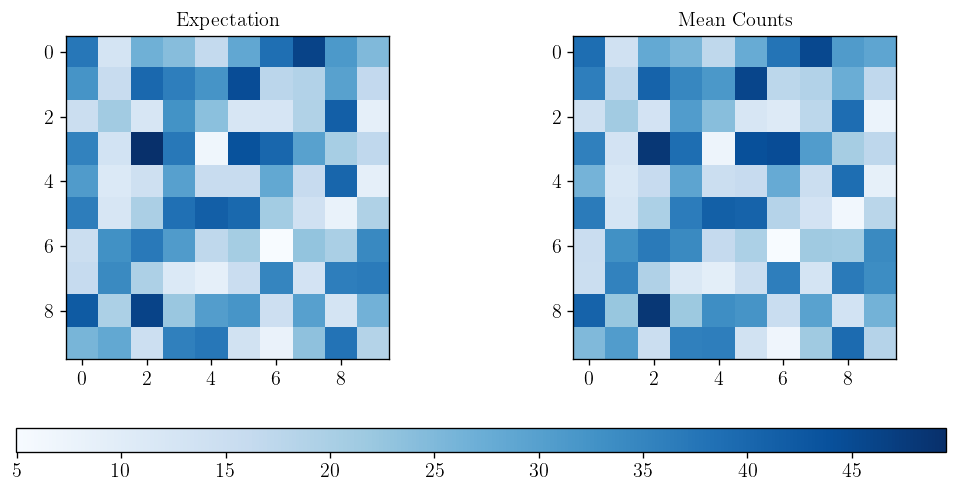

In [67]:
mean_counts = np.zeros_like(data_s[0], dtype=np.float64)
for i in range(n_sim):
    mean_counts += data_s[i]
mean_counts /= float(n_sim)

expectation = np.zeros_like(data_s[0], dtype=np.float64)
for i in range(5):
    if f'Sps_t{i}' in vd and vd[f'Sps_t{i}'] is not None:
        expectation += temps[i] * vd[f'Sps_t{i}']

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
vmin, vmax = np.min(expectation), np.max(expectation)
axs[0].imshow(expectation.reshape(10, 10), vmin=vmin, vmax=vmax, cmap='Blues')
im = axs[1].imshow(mean_counts.reshape(10, 10), vmin=vmin, vmax=vmax, cmap='Blues')
fig.colorbar(im, ax=axs, orientation='horizontal', aspect=40)
axs[0].set_title('Expectation')
axs[1].set_title('Mean Counts');

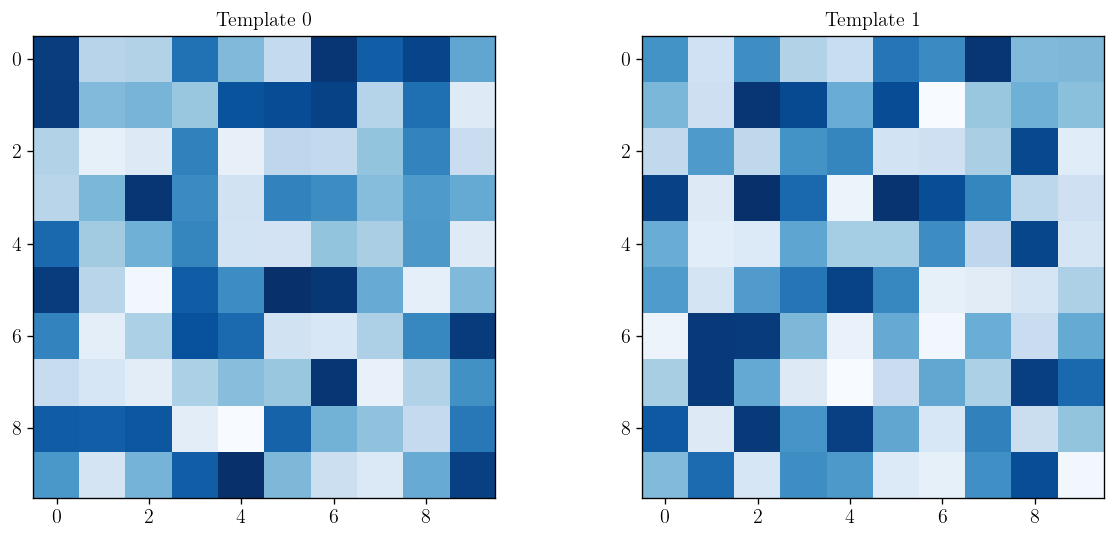

In [68]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(temps[0].reshape(10, 10), cmap='Blues')
axs[1].imshow(temps[1].reshape(10, 10), cmap='Blues')
axs[0].set_title('Template 0')
axs[1].set_title('Template 1');

mean =  25.006


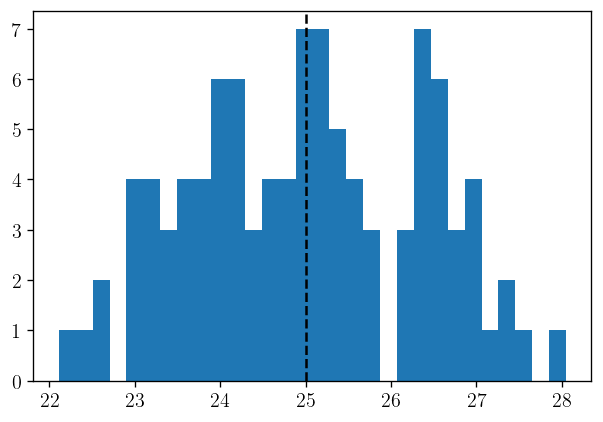

In [69]:
plt.hist(np.mean(data_s, axis=1), bins=30)
plt.axvline(np.mean(expectation), color='k', ls='--')
print('mean = ', np.mean(data_s))

## scan

In [36]:
import cProfile
import pstats
import io

In [ ]:
pr = cProfile.Profile()
pr.enable()

for _ in range(200):
    log_like(pt_sum_compressed, theta, npt_compressed, data)

pr.disable()
s = io.StringIO()
sortby = 'cumulative'
ps = pstats.Stats(pr, stream=s).sort_stats(sortby)
ps.print_stats(30)
print(s.getvalue())

In [70]:
pt_sum_compressed = np.zeros_like(temps[0])
npt_compressed = [temps[i] for i in range(5) if i in include_temps]

Sps_key = 't0'

Sps_arr = np.linspace(0.5*vd['Sps_'+Sps_key], 1.5*vd['Sps_'+Sps_key], 50)
#Sps_arr = np.linspace(0.1, 1, 50)

ll_ss = []
counts_arr = []
for data in tqdm(data_s[:50]):
    ll_s = []
    counts_arr.append(np.sum(data))
    for Sps_target in Sps_arr:
        theta = []
        for i in include_temps:
            key = f't{i}'
            Sps = vd['Sps_'+key]
            if key == Sps_key:
                Sps = Sps_target
            
            s_intg = temp_s_intg_s[i] # expected counts for dndS with (1, n1, n2, n3, sb1, sb2)
            A = Sps / s_intg

            _, n1, n2, n3, sb1, sb2 = theta_unnorm_i(i, vd)
            theta.append([A, n1, n2, n3, sb1, sb2])

        ll = log_like(pt_sum_compressed, theta, npt_compressed, data)
        ll_s.append(ll)
    ll_ss.append(ll_s)

100%|██████████| 50/50 [01:28<00:00,  1.76s/it]


## plot

In [ ]:
vd

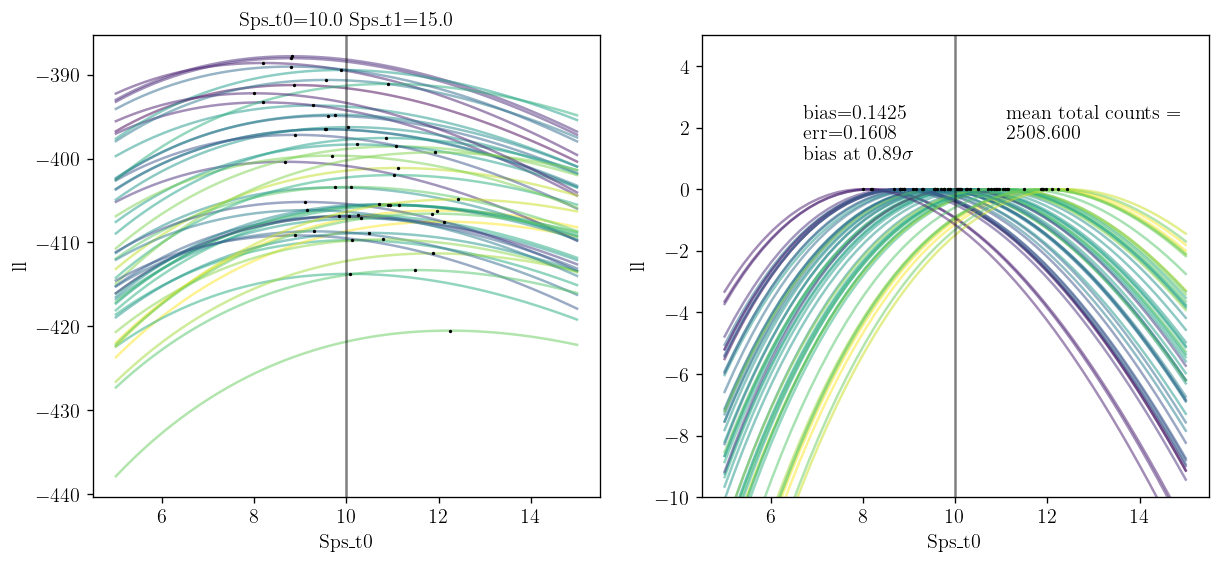

In [71]:
ll_ss = np.array(ll_ss).astype(np.float64)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

max_x_s = []
max_y_s = []
Sps_s = Sps_arr

for i in range(50):
    ax = axs[0]
    color_x = (counts_arr[i] - np.min(counts_arr)) / (np.max(counts_arr) - np.min(counts_arr))
    color = cms['viridis'](color_x)
    rll = ll_ss[i]
    ax.plot(Sps_s, rll, color=color, alpha=0.5)
    max_x, max_y = find_max_point(Sps_s, rll)
    ax.plot(max_x, max_y, 'k.', ms=2, zorder=10)
    max_x_s.append(max_x)
    max_y_s.append(max_y)

    ax = axs[1]
    rll = ll_ss[i] - np.max(ll_ss[i])
    ax.plot(Sps_s, rll, color=color, alpha=0.5)
    max_x, max_y = find_max_point(Sps_s, rll)
    ax.plot(max_x, max_y, 'k.', ms=2, zorder=10)

title_str = " ".join([f"Sps_{k}={vd['Sps_'+k]}" for k in ['t0', 't1']])

ax = axs[0]
ax.axvline(vd['Sps_'+Sps_key], color='k', ls='-', alpha=0.5)
ax.set(title=title_str, xlabel="Sps_"+Sps_key, ylabel='ll')

ax = axs[1]
ax.axvline(vd['Sps_'+Sps_key], color='k', ls='-', alpha=0.5)
ax.set(ylim=(-10, 5))
ax.set(xlabel="Sps_"+Sps_key, ylabel='ll')

bias = (np.mean(max_x_s) - vd['Sps_'+Sps_key])
err = np.std(max_x_s) / np.sqrt(len(max_x_s))
bias_sigma = bias/err

ax.text(0.2, 0.85, f"bias={bias:.4f}\nerr={err:.4f}\nbias at {bias_sigma:.2f}"+r"$\sigma$", transform=ax.transAxes, va='top')
ax.text(0.6, 0.85, f"mean total counts = \n{np.mean(counts_arr):.3f}", transform=ax.transAxes, va='top');

In [57]:
10/np.mean(max_x_s)

16.294843045259952